# 00 — Dataset exploration: Amazon Reviews 2023 (McAuley Lab)

This notebook answers two questions, in order, before we build the real collection
pipeline (`01_data_collection.ipynb`):

1. **Where does Electronics sit in the whole dataset?** (a cheap, citation-backed
   overview of all 33 categories — not a full EDA of each one, just enough to justify
   the choice of Electronics with real numbers instead of assumption)
2. **What does Electronics actually look like?** (a real exploratory analysis: nulls,
   price distribution, top brands by volume, rating distribution) — this is also the
   step that should have caught the Sony/AKG over-matching problem *before* building
   the filter, not after.

---
## 1.&nbsp; Install dependencies 📦

⚠️ **Compatibility note:** this dataset uses a custom Hugging Face "loading script".
`datasets>=4.0` removed `trust_remote_code` support, so we must pin below 4.0.

In [17]:
%pip install "datasets<4.0" pandas matplotlib --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import json
import itertools
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

pd.set_option("display.max_colwidth", 80)


def find_project_root(marker="requirements.txt"):
    path = Path.cwd()
    for parent in [path] + list(path.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"Could not find project root (looking for {marker})")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
print("Project root detected successfully.")
# print("Project root:", PROJECT_ROOT)

Project root detected successfully.


---
## 2.&nbsp; Global overview — where does Electronics sit? 🗺️

We do **not** download all 33 categories to answer this — McAuley Lab already
publishes per-category counts on the official project site. Reproducing that work
by re-downloading everything would be wasted effort given our scope is already
fixed to Electronics → premium audio.

Source: https://amazon-reviews-2023.github.io/ (official statistics table, retrieved
July 2026). This table is transcribed here for reference and citation — not computed.

In [8]:
# Official per-category stats, McAuley Lab (https://amazon-reviews-2023.github.io/)
# Only the top categories by #Users are shown here for context; see the source
# site for the full table of all 33 categories.
official_stats = pd.DataFrame([
    {"category": "Home_and_Kitchen", "users_m": 23.2, "items_m": 3.7, "ratings_m": 67.4},
    {"category": "Clothing_Shoes_and_Jewelry", "users_m": 22.6, "items_m": 7.2, "ratings_m": 66.0},
    {"category": "Electronics", "users_m": 18.3, "items_m": 1.6, "ratings_m": 43.9},
    {"category": "Health_and_Household", "users_m": 12.5, "items_m": 0.80, "ratings_m": 25.6},
    {"category": "Cell_Phones_and_Accessories", "users_m": 11.6, "items_m": 1.3, "ratings_m": 20.8},
    {"category": "Beauty_and_Personal_Care", "users_m": 11.3, "items_m": 1.0, "ratings_m": 23.9},
])

official_stats["rank_by_users"] = official_stats["users_m"].rank(ascending=False).astype(int)
official_stats.sort_values("users_m", ascending=False)

,category,users_m,items_m,ratings_m,rank_by_users
0,Home_and_Kitchen,23.2,3.7,67.4,1
1,Clothing_Shoes_and_Jewelry,22.6,7.2,66.0,2
2,Electronics,18.3,1.6,43.9,3
3,Health_and_Household,12.5,0.8,25.6,4
4,Cell_Phones_and_Accessories,11.6,1.3,20.8,5
5,Beauty_and_Personal_Care,11.3,1.0,23.9,6


**Takeaway:** Electronics is the **3rd largest category by users** (18.3M) out of 33,
with 1.6M items and 43.9M ratings — large enough that narrowing down to a specific
premium product niche still leaves a meaningful amount of real data, not a
statistically thin slice.

---
## 3.&nbsp; Load Electronics metadata (full) 🏷️

This is the same load used in `01_data_collection.ipynb` — no `streaming=True` here,
because at ~1.6M rows the metadata table is manageable to scan directly.

In [9]:
meta_full = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    trust_remote_code=True,
)
print(f"Total Electronics products in metadata: {len(meta_full):,}")

Total Electronics products in metadata: 1,610,012


---
## 4.&nbsp; Real EDA on Electronics metadata 🔍

This is the part the first version of this notebook was missing. Iterating once
over the full table (instead of converting everything to a pandas DataFrame, which
would be memory-heavy given the nested `images`/`videos`/`features` fields).

In [10]:
def parse_price(price_str):
    """Price comes as a free-text string (e.g. '$29.99', 'None', ''). Returns float or None."""
    if not price_str or price_str == "None":
        return None
    cleaned = price_str.replace("$", "").replace(",", "").strip()
    try:
        return float(cleaned)
    except ValueError:
        return None


null_counts = Counter()
store_counts = Counter()
prices = []
ratings = []
total = 0

FIELDS_TO_CHECK = ["store", "price", "title", "average_rating", "rating_number"]

for row in meta_full:
    total += 1
    for field in FIELDS_TO_CHECK:
        val = row.get(field)
        if val is None or val == "" or val == "None":
            null_counts[field] += 1

    store = row.get("store")
    if store:
        store_counts[store] += 1

    price = parse_price(row.get("price"))
    if price is not None:
        prices.append(price)

    rating = row.get("average_rating")
    if rating is not None:
        ratings.append(rating)

print(f"Total products scanned: {total:,}\n")
print("Null / missing rate per field:")
for field in FIELDS_TO_CHECK:
    pct = null_counts[field] / total * 100
    print(f"  {field}: {pct:.1f}% missing")

Total products scanned: 1,610,012

Null / missing rate per field:
  store: 0.6% missing
  price: 67.3% missing
  title: 0.0% missing
  average_rating: 0.0% missing
  rating_number: 0.0% missing


In [11]:
prices_series = pd.Series(prices)
print("Price stats (USD, only rows where price was present):")
print(prices_series.describe())

print("\nThis directly informs whether MIN_PRICE = 150 (used in 01_data_collection.ipynb)")
print("is a reasonable premium threshold, or needs adjusting.")

Price stats (USD, only rows where price was present):
count    526449.000000
mean         96.457675
std         319.173788
min           0.000000
25%          11.990000
50%          22.900000
75%          60.000000
max       44630.000000
dtype: float64

This directly informs whether MIN_PRICE = 150 (used in 01_data_collection.ipynb)
is a reasonable premium threshold, or needs adjusting.


In [12]:
top_stores = store_counts.most_common(20)
top_stores_df = pd.DataFrame(top_stores, columns=["store", "product_count"])
print("Top 20 stores by number of listed products in Electronics:")
top_stores_df

Top 20 stores by number of listed products in Electronics:


,store,product_count
0,Amazon Renewed,30576
1,HP,17129
2,Sony,14160
3,Generic,13499
4,SAMSUNG,11503
5,Lenovo,9049
6,Dell,7042
7,ASUS,6870
8,Neewer,6755
9,Fintie,5370


**Why this matters:** this is exactly the view that would have flagged the
Sony/AKG over-matching problem *before* building `01_data_collection.ipynb`'s
filter, not after running it. If a brand shows an implausibly large product count
here, that's the signal to filter by product line, not just by brand name.

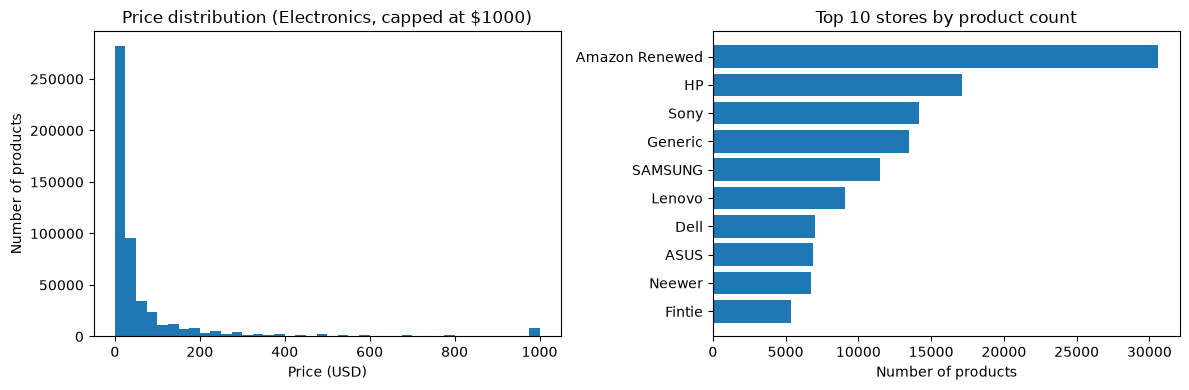

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prices_series.clip(upper=1000), bins=40)
axes[0].set_title("Price distribution (Electronics, capped at $1000)")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Number of products")

axes[1].barh(top_stores_df["store"][:10][::-1], top_stores_df["product_count"][:10][::-1])
axes[1].set_title("Top 10 stores by product count")
axes[1].set_xlabel("Number of products")

plt.tight_layout()
plt.show()

---
## 5.&nbsp; Sample reviews (streaming) — rating distribution + date range 📝

The reviews table is far larger than metadata, so we stream it and only materialize
a sample — enough for distribution stats, not the full table.

In [14]:
reviews_stream = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True,
)

SAMPLE_SIZE = 20_000
review_sample = list(itertools.islice(reviews_stream, SAMPLE_SIZE))
df_reviews_sample = pd.DataFrame(review_sample)
df_reviews_sample["date"] = pd.to_datetime(df_reviews_sample["timestamp"], unit="ms")

print(f"Sample size: {len(df_reviews_sample):,} reviews")
print(f"Date range in this sample: {df_reviews_sample['date'].min()} to {df_reviews_sample['date'].max()}")
print(f"Verified purchase rate: {df_reviews_sample['verified_purchase'].mean() * 100:.1f}%")
print("\nRating distribution:")
print(df_reviews_sample["rating"].value_counts().sort_index())

Sample size: 20,000 reviews
Date range in this sample: 2001-08-11 00:26:51 to 2023-03-18 02:35:08.237000
Verified purchase rate: 72.0%

Rating distribution:
rating
1.0     1458
2.0      740
3.0     1307
4.0     2848
5.0    13647
Name: count, dtype: int64


**Note on sampling order:** streaming reads rows in the dataset's stored order, which
is not guaranteed to be random — this sample is best read as "an early slice", not a
statistically random sample of all Electronics reviews. Good enough to sanity-check
structure and rough distributions; not something to cite as a precise population
statistic in the final report.

---
## 6.&nbsp; Export schema + samples 🗂️

Schema generated programmatically from each dataset's `Features` object — not typed
by hand — so it stays accurate even if Hugging Face updates the structure.

In [16]:
def features_to_schema(features):
    return {col: str(feat) for col, feat in features.items()}


schema = {
    "dataset": "McAuley-Lab/Amazon-Reviews-2023",
    "configs": {
        "raw_meta_Electronics": {
            "num_columns": len(meta_full.features),
            "columns": features_to_schema(meta_full.features),
            "join_key": "parent_asin",
        },
        "raw_review_Electronics": {
            "num_columns": len(reviews_stream.features),
            "columns": features_to_schema(reviews_stream.features),
            "join_key": "parent_asin",
        },
    },
}

output_dir = DATA_DIR / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

with open(output_dir / "schema_amazon_reviews_2023.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, indent=2, ensure_ascii=False)

top_stores_df.to_csv(output_dir / "electronics_top_stores.csv", index=False)
df_reviews_sample.head(1000).to_csv(output_dir / "sample_1000_raw_review_Electronics.csv", index=False)

print("Saved to: data/processed")
print("- schema_amazon_reviews_2023.json")
print("- electronics_top_stores.csv")
print("- sample_1000_raw_review_Electronics.csv")

Saved to: data/processed
- schema_amazon_reviews_2023.json
- electronics_top_stores.csv
- sample_1000_raw_review_Electronics.csv


---
## 7.&nbsp; Key takeaways 🔑

* Electronics is the right level to drill into: 3rd largest of 33 categories by
  users (source: official McAuley Lab stats page), large enough to support a
  narrower premium-audio slice without running out of data.
* The dataset ships in **two separate tables** (`raw_meta_*` / `raw_review_*`)
  joined by `parent_asin` — brand lives only in metadata.
* `price` is a **free-text field**, not always present — needs parsing and null
  handling before any price-based filtering (this justifies the `MIN_PRICE`
  safety-net logic in `01_data_collection.ipynb`).
* Top-store counts are the diagnostic that should catch brand/product
  over-matching *before* building a filter — this is what we were missing when
  Sony matched 1,154 products and AKG leaked into the Sennheiser bucket.
* `timestamp` is epoch **milliseconds**, not seconds.
* Next step: use these findings to sanity-check the brand/product-line filter in
  `01_data_collection.ipynb` before trusting its output for the ground truth.